In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import math
from math import sqrt
import ROOT
import ctypes
try:
#     plt.style.use('belle2')
    plt.style.use('belle2_serif')
#     plt.style.use('belle2_modern')
except OSError:
    print("Please install belle2 matplotlib style") 
px = 1/plt.rcParams['figure.dpi']

from main.data_tools.extract_ntuples import get_pd, get_np
from main.draw_tools.decorations import b2helix, watermark
from main.draw_tools.stacking_with_error_bars import MC_stack_plot, MC_stack_plot_density

from main.data_tools.error_bars import make_data_weight
from main.data_tools.query_dataframes import cut_dfs_7types

from matplotlib.ticker import ScalarFormatter


Welcome to JupyROOT 6.26/04


In [2]:
def cal_Br_Central_value(Nsig, Nref, eff_sig, eff_ref, Br_ref_dec):
    print("Input values:")
    print("Nsig:", Nsig)
    print("Nref:", Nref)
    print("eff_sig:", eff_sig)
    print("eff_ref:", eff_ref)
    print("Br_ref_dec:", Br_ref_dec)
    
    N_real_sig = Nsig / eff_sig
    N_real_ref = Nref / eff_ref
    
    Br = Br_ref_dec * (N_real_sig / N_real_ref)
    
    return Br
    
from math import sqrt

def cal_Br_error_stat(Nsig_err, Nsig, Nref_err, Nref, central_value):
    Variance = (Nsig_err / Nsig)**2 + (Nref_err / Nref)**2
    TOTAL = sqrt(Variance) * central_value
    return TOTAL

def cal_Br_error_with_eff(Nsig_err, Nsig, Nref_err, Nref, eff_sig_err, eff_sig, eff_ref_err, eff_ref, central_value):
    Variance = (Nsig_err / Nsig)**2 + (eff_sig_err / eff_sig)**2 + (Nref_err / Nref)**2 + (eff_ref_err / eff_ref)**2
    TOTAL = sqrt(Variance) * central_value
    return TOTAL


In [3]:
from math import sqrt

# Function to calculate the central branching ratio value
def calculate_br(Nsig, Nref, eff_sig, eff_ref, Br_ref_dec):
    N_real_sig = Nsig / eff_sig
    N_real_ref = Nref / eff_ref
    Br = Br_ref_dec * (N_real_sig / N_real_ref)
    return Br
    
def calculate_br_ratio(Nsig,Nsig_err,  Nref,Nref_err, eff_sig, eff_ref):
    N_real_sig = Nsig / eff_sig
    N_real_ref = Nref / eff_ref
    Br_ratio = (N_real_sig / N_real_ref)
    Br_ratio_err = (eff_ref/eff_sig) * math.sqrt( (Nsig_err / Nref)**2 + (Nsig / (Nref**2) * Nref_err)**2 )
    print(f'Br_ratio value = {Br_ratio:.4e}')
    print(f'Br_ratio Statistical uncertainty = {Br_ratio_err:.4e}')
    return Br_ratio, Br_ratio_err

# Function to calculate statistical uncertainty
def calculate_stat_uncertainty(Nsig_err, Nsig, Nref_err, Nref, central_value):
    variance = (Nsig_err / Nsig)**2 + (Nref_err / Nref)**2
    return sqrt(variance) * central_value

# Function to print results in a formatted way
def print_results(label, central_value, stat_unc, Br_sig_dec):
    pull = (central_value - Br_sig_dec) / stat_unc
    print(f'{label} Central value = {central_value:.4e}')
    print(f'{label} Statistical uncertainty = {stat_unc:.4e}')
    print(f'{label} Pull = {pull:.4f}')
    print(f'{label} stas. unc./Central value = {stat_unc/central_value:.4e}\n')

# Error-weighted combination function
def combine_error_weighted(x, y, x_err, y_err):
    central_value = (x / x_err**2 + y / y_err**2) / (1 / x_err**2 + 1 / y_err**2)
    error = 1 / sqrt(1 / x_err**2 + 1 / y_err**2)
    return central_value, error

In [4]:
# signal_eff_error = math.sqrt(signal_eff * (1 - signal_eff) / N_gen)

def calculate_sig_eff_err(eff, N_gen):

    error = math.sqrt(eff * (1 - eff) / N_gen)
    return error

# Br(D+ -> eta K+)

In [5]:
# Constants
Br_ref_dec = 0.003770000
Br_sig_dec = 0.000125000

Br_sig_PDG = 0.0001250000
Br_sig_PDG_err = 0.0000160000


In [6]:
# 0.91
eff_sig_cal =  0.0455
eff_ref_cal =  0.0631

In [7]:


eff_sig_err_cal = calculate_sig_eff_err(eff_sig_cal, 6e+6)

eff_sig_err_cal


eff_ref_err_cal = calculate_sig_eff_err(eff_ref_cal, 6e+6)
eff_ref_err_cal

print(f"signal eff error: {eff_sig_err_cal:.6e}, ref eff error: {eff_ref_err_cal:.6e}")

signal eff error: 8.507815e-05, ref eff error: 9.926261e-05


In [8]:
# First calculation for mode: eta -> gg
Nsig_err, Nsig, Nref_err, Nref = 43.23205936648267, 533.8335242441342 , 210.14669520339157 , 22406.767936898214
# Nsig_err, Nsig, Nref_err, Nref = , , ,

eff_sig_err, eff_sig, eff_ref_err, eff_ref = eff_sig_err_cal, eff_sig_cal, eff_ref_err_cal, eff_ref_cal

central_value_1 = calculate_br(Nsig, Nref, eff_sig, eff_ref, Br_ref_dec)
stat_unc_1 = calculate_stat_uncertainty(Nsig_err, Nsig, Nref_err, Nref, central_value_1)
print_results("Mode: eta -> gg", central_value_1, stat_unc_1, Br_sig_dec)


Mode: eta -> gg Central value = 1.2456e-04
Mode: eta -> gg Statistical uncertainty = 1.0155e-05
Mode: eta -> gg Pull = -0.0431
Mode: eta -> gg stas. unc./Central value = 8.1525e-02



In [9]:
ratio_central_Br_gg, ratio_err_Br_gg  = calculate_br_ratio(Nsig,Nsig_err, Nref, Nref_err, eff_sig, eff_ref)


Br_ratio value = 3.3040e-02
Br_ratio Statistical uncertainty = 2.6936e-03


In [10]:
# 0.92
eff_sig_cal =  0.0381
eff_ref_cal = 0.0524

In [11]:
eff_sig_err_cal = calculate_sig_eff_err(eff_sig_cal, 6e+6)

eff_ref_err_cal = calculate_sig_eff_err(eff_ref_cal, 6e+6)

print(f"signal eff error: {eff_sig_err_cal:.6e}, ref eff error: {eff_ref_err_cal:.6e}")

signal eff error: 7.815411e-05, ref eff error: 9.097091e-05


In [12]:
# Second calculation for mode: eta -> pipipi
Nsig_err, Nsig, Nref_err, Nref = 23.288942474989838, 264.94003796983776 , 123.61477929656485 , 11273.896780101566
# Nsig_err, Nsig, Nref_err, Nref =, , ,

eff_sig_err, eff_sig, eff_ref_err, eff_ref = eff_sig_err_cal, eff_sig_cal ,eff_ref_err_cal,eff_ref_cal

central_value_2 = calculate_br(Nsig, Nref, eff_sig, eff_ref, Br_ref_dec)
stat_unc_2 = calculate_stat_uncertainty(Nsig_err, Nsig, Nref_err, Nref, central_value_2)
print_results("Mode: eta -> pipipi", central_value_2, stat_unc_2, Br_sig_dec)

Mode: eta -> pipipi Central value = 1.2185e-04
Mode: eta -> pipipi Statistical uncertainty = 1.0794e-05
Mode: eta -> pipipi Pull = -0.2919
Mode: eta -> pipipi stas. unc./Central value = 8.8584e-02



In [13]:
ratio_central_Br_3pi, ratio_err_Br_3pi  = calculate_br_ratio(Nsig,Nsig_err, Nref, Nref_err, eff_sig, eff_ref)


Br_ratio value = 3.2321e-02
Br_ratio Statistical uncertainty = 2.8631e-03


In [17]:
# Combined error-weighted result
combined_central_value, combined_error = combine_error_weighted(central_value_1, central_value_2, stat_unc_1, stat_unc_2)
print_results("Combined", combined_central_value, combined_error, Br_sig_dec)

Combined Central value = 1.2329e-04
Combined Statistical uncertainty = 7.3962e-06
Combined Pull = -0.2315
Combined stas. unc./Central value = 5.9991e-02



In [15]:
# Combined error-weighted result
combined_central_value, combined_error = combine_error_weighted(ratio_central_Br_gg,ratio_central_Br_3pi, ratio_err_Br_gg, ratio_err_Br_3pi)
print_results("Combined", combined_central_value, combined_error, 0.125/3.77)

0.125/3.77

Combined Central value = 3.2702e-02
Combined Statistical uncertainty = 1.9619e-03
Combined Pull = -0.2315
Combined stas. unc./Central value = 5.9991e-02



0.033156498673740056

In [65]:
# (7.2806e-06-0.17/10000)/(0.17/10000)*100

In [77]:
(0.17/10000 - 7.5365e-06)/(0.17/10000)

0.5566764705882353

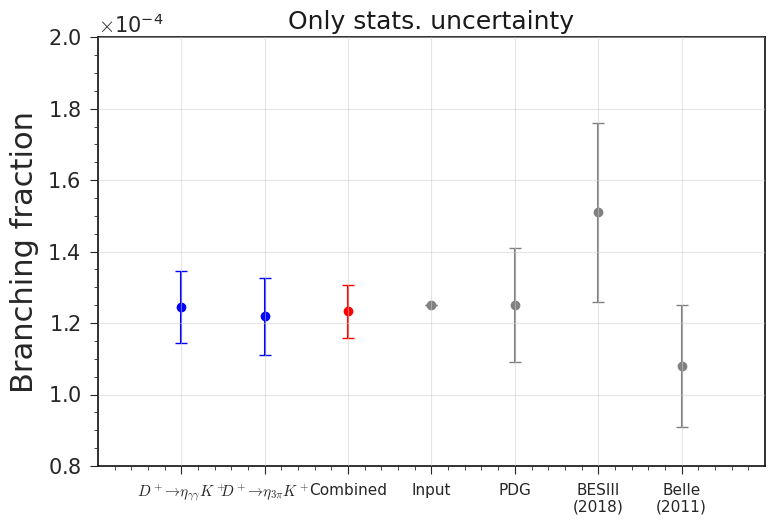

In [18]:
# Plotting
plt.errorbar(1, central_value_1, yerr=stat_unc_1, fmt='o', capsize=4,color='blue')
plt.errorbar(2, central_value_2, yerr=stat_unc_2, fmt='o', capsize=4, color='blue')
plt.errorbar(3, combined_central_value, yerr=combined_error, fmt='o', capsize=4, color='red')
plt.errorbar(4, Br_sig_dec, yerr=0, fmt='o', capsize=4, label='Input',color='gray')
plt.errorbar(5, Br_sig_PDG, yerr=Br_sig_PDG_err, fmt='o', capsize=4,color='gray')
plt.errorbar(6, 0.151/1000, yerr=0.025/1000, fmt='o', capsize=4,color='gray')
plt.errorbar(7, 1.08/10000, yerr=0.17/10000, fmt='o', capsize=4,color='gray')

# Customizing plot
plt.xticks([1, 2, 3, 4, 5, 6, 7], [r'$D^+ \to \eta_{\gamma\gamma} K^+$', r'$D^+ \to \eta_{3\pi} K^+$', 'Combined','Input','PDG','BESIII\n(2018)','Belle\n(2011)'], fontsize=11)
# plt.xticks([1, 2, 3, 4], [r'$D^+ \to \eta_{\gamma\gamma} K^+$', r'$D^+ \to \eta_{3\pi} K^+$', 'Combined','Input','PDG'], fontsize=12)

plt.gca().yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
plt.ticklabel_format(axis="y", style="sci", scilimits=(0,0))

plt.ylabel('Branching fraction')
plt.grid(True, alpha=0.5)
plt.title("Only stats. uncertainty")
# plt.legend()
plt.tight_layout()
plt.savefig("MC15rd_427_87_etaKp_gg_Br_fix_v10_bdt_Dp_CMS_p_new_Ds_correct.best_Nsigma.weighted.png")
# plt.savefig("MC15rd_427_87_etaKp_gg_Br_fix_v7_bdt_Dp_CMS_p_new_range.best_FOM.weighted.png")

plt.show()

# Br(Ds+ -> eta K+)

In [19]:
# Constants
Br_ref_dec = 0.017000000
Br_sig_dec = 0.001600000

Br_sig_PDG = 0.001730000
Br_sig_PDG_err = 0.000080000


In [20]:
# 0.91
eff_sig_cal = 0.0386
eff_ref_cal = 0.0544

In [21]:
eff_sig_err_cal = calculate_sig_eff_err(eff_sig_cal,  6e+6)
eff_ref_err_cal = calculate_sig_eff_err(eff_ref_cal, 6e+6)
print(f"signal eff error: {eff_sig_err_cal:.6e}, ref eff error: {eff_ref_err_cal:.6e}")

signal eff error: 7.864481e-05, ref eff error: 9.259287e-05


In [22]:
# First calculation for mode: eta -> gg
Nsig_err, Nsig, Nref_err, Nref = 73.30410080842262, 3127.0525804656004, 242.4697212229985 , 47273.768092928294
# Nsig_err, Nsig, Nref_err, Nref =  , , ,

eff_sig_err, eff_sig, eff_ref_err, eff_ref = eff_sig_err_cal, eff_sig_cal, eff_ref_err_cal, eff_ref_cal

central_value_1 = calculate_br(Nsig, Nref, eff_sig, eff_ref, Br_ref_dec)
stat_unc_1 = calculate_stat_uncertainty(Nsig_err, Nsig, Nref_err, Nref, central_value_1)
print_results("Mode: eta -> gg", central_value_1, stat_unc_1, Br_sig_dec)

Mode: eta -> gg Central value = 1.5848e-03
Mode: eta -> gg Statistical uncertainty = 3.8030e-05
Mode: eta -> gg Pull = -0.3996
Mode: eta -> gg stas. unc./Central value = 2.3996e-02



In [23]:
ratio_central_Br_gg, ratio_err_Br_gg  = calculate_br_ratio(Nsig,Nsig_err, Nref, Nref_err, eff_sig, eff_ref)


Br_ratio value = 9.3224e-02
Br_ratio Statistical uncertainty = 2.2370e-03


In [24]:
# 0.92
eff_sig_cal  =  0.0276
eff_ref_cal =  0.0392

In [25]:
eff_sig_err_cal = calculate_sig_eff_err(eff_sig_cal, 6e+6)
eff_sig_err_cal
# eff_ref_err_cal = calculate_sig_eff_err(0.02653, 2e+6)
eff_ref_err_cal = calculate_sig_eff_err(eff_ref_cal, 6e+6)

print(f"signal eff error: {eff_sig_err_cal:.6e}, ref eff error: {eff_ref_err_cal:.6e}")

signal eff error: 6.688079e-05, ref eff error: 7.922895e-05


In [26]:
# Second calculation for mode: eta -> pipipi
Nsig_err, Nsig, Nref_err, Nref = 41.070609843501074 , 1310.6394390681576 , 149.0261848133723,19798.445187596266
# Nsig_err, Nsig, Nref_err, Nref = , , ,
eff_sig_err, eff_sig, eff_ref_err, eff_ref = eff_sig_err_cal, eff_sig_cal , eff_ref_err_cal, eff_ref_cal

central_value_2 = calculate_br(Nsig, Nref, eff_sig, eff_ref, Br_ref_dec)
stat_unc_2 = calculate_stat_uncertainty(Nsig_err, Nsig, Nref_err, Nref, central_value_2)
print_results("Mode: eta -> pipipi", central_value_2, stat_unc_2, Br_sig_dec)

Mode: eta -> pipipi Central value = 1.5984e-03
Mode: eta -> pipipi Statistical uncertainty = 5.1512e-05
Mode: eta -> pipipi Pull = -0.0316
Mode: eta -> pipipi stas. unc./Central value = 3.2228e-02



In [27]:
ratio_central_Br_3pi, ratio_err_Br_3pi  = calculate_br_ratio(Nsig,Nsig_err, Nref, Nref_err, eff_sig, eff_ref)


Br_ratio value = 9.4022e-02
Br_ratio Statistical uncertainty = 3.0301e-03


In [30]:
# Combined error-weighted result
combined_central_value, combined_error = combine_error_weighted(central_value_1, central_value_2, stat_unc_1, stat_unc_2)
print_results("Combined", combined_central_value, combined_error, Br_sig_dec)

Combined Central value = 1.5896e-03
Combined Statistical uncertainty = 3.0595e-05
Combined Pull = -0.3402
Combined stas. unc./Central value = 1.9247e-02



In [29]:
# Combined error-weighted result
combined_central_value, combined_error = combine_error_weighted(ratio_central_Br_gg,ratio_central_Br_3pi, ratio_err_Br_gg, ratio_err_Br_3pi)
print_results("Combined", combined_central_value, combined_error, 0.160/1.70)

0.160/1.70

Combined Central value = 9.3505e-02
Combined Statistical uncertainty = 1.7997e-03
Combined Pull = -0.3402
Combined stas. unc./Central value = 1.9247e-02



0.09411764705882353

In [79]:
( 0.05/1000 - 3.0449e-05) / (0.05/1000)

0.39102000000000003

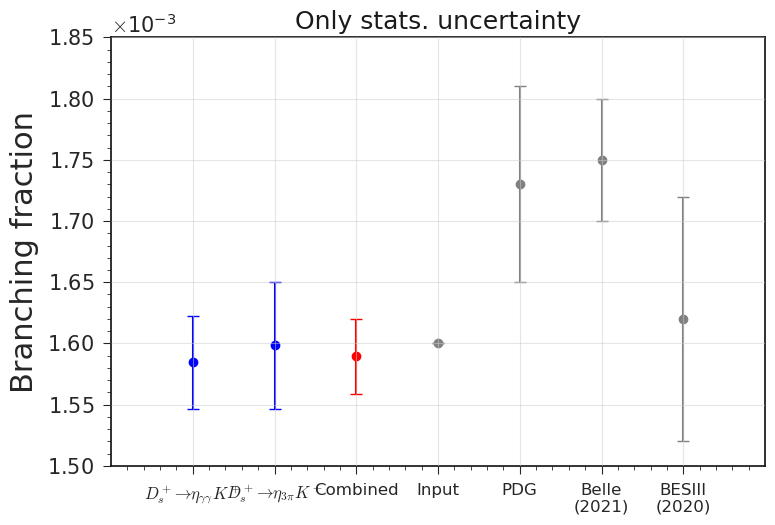

In [31]:
# Plotting
plt.errorbar(1, central_value_1, yerr=stat_unc_1, fmt='o', capsize=4,color='blue')
plt.errorbar(2, central_value_2, yerr=stat_unc_2, fmt='o', capsize=4,color='blue')
plt.errorbar(3, combined_central_value, yerr=combined_error, fmt='o', capsize=4,color='red')
plt.errorbar(4, Br_sig_dec, yerr=0, fmt='o', capsize=4, label='Input',color='gray')
plt.errorbar(5, Br_sig_PDG, yerr=Br_sig_PDG_err, fmt='o', capsize=4,color='gray')
plt.errorbar(6, 1.75/1000, yerr=0.05/1000, fmt='o', capsize=4,color='gray')
plt.errorbar(7, 1.62/1000, yerr=0.1/1000, fmt='o', capsize=4,color='gray')

# Customizing plot
plt.xticks([1, 2, 3, 4, 5, 6, 7], [r'$D_s^+ \to \eta_{\gamma\gamma} K^+$', r'$D_s^+ \to \eta_{3\pi} K^+$', 'Combined','Input','PDG','Belle\n(2021)','BESIII\n(2020)'], fontsize=12)
# plt.xticks([1, 2, 3, 4], [r'$D^+ \to \eta_{\gamma\gamma} K^+$', r'$D^+ \to \eta_{3\pi} K^+$', 'Combined','Input','PDG'], fontsize=12)

plt.gca().yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
plt.ticklabel_format(axis="y", style="sci", scilimits=(0,0))

plt.ylabel('Branching fraction')
plt.grid(True, alpha=0.5)
plt.title("Only stats. uncertainty")

# plt.legend()
plt.tight_layout()
# plt.savefig("MC15rd_427_87_etaKp_gg_Ds_Br_v7.png")
plt.savefig("MC15rd_427_87_etaKp_gg_Ds_Br_fix_v10_bdt_Dp_CMS_p_new_Ds_correct.best_Nsigma.weighted.png")
# plt.savefig("MC15rd_427_87_etaKp_gg_Ds_Br_fix_v7_bdt_Dp_CMS_p_new_range.best_FOM.weighted.png")


plt.show()